# Classificacao com modelos diversos, usando Ensemble

Implementaremos modelos de reconhecimento de mal de parkinson atraves da voz.

Veja [aqui](https://archive.ics.uci.edu/ml/datasets/Parkinson%27s+Disease+Classification) os detalhes sobre o **dataset** utilizado.

Observe os comentários de códigos iniciados pela tag #TODO, contendo as instruções para sua implementação.


# Todos os imports

In [1]:
import requests
from io import StringIO
from sklearn import neighbors, naive_bayes, neural_network, svm, tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,  roc_curve, auc, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, VotingClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy import interp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import tabulate

# Load

In [2]:
orig_url='https://drive.google.com/file/d/1gQzKI5pgJUZfO44hnAB-DMVI0pMpTUXU/view?usp=sharing'
file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text
csv_raw = StringIO(url)

df = pd.read_csv(csv_raw, header=1) # inicia leitura na 2a linha
df.drop(['id'], 1, inplace=True) # remove coluna id
df.head()

/tmp/ipykernel_49984/3229907949.py:8: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  df.drop(['id'], 1, inplace=True) # remove coluna id


,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,locAbsJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,0.000018,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,0.000016,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,0.000015,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,0.000046,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,0.000044,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [3]:
df['class'].value_counts()

1    564
0    192
Name: class, dtype: int64

# Split

In [4]:
X = np.array(df.drop(['class'], axis=1))
y = np.array(df['class'])

In [5]:
X.shape

(756, 753)

In [6]:
y.shape

(756,)

# Standardization (Padronizacao)

In [7]:
scaler = StandardScaler()
Z = scaler.fit_transform(X)
print(Z.shape)

(756, 753)


# PCA

In [8]:
pca = PCA(n_components = 0.95) #TODO
Z_PCA = pca.fit_transform(Z)
Z = Z_PCA

In [9]:
print(Z_PCA.shape)

(756, 168)


# Geracao dos Modelos

In [10]:
# KNN
knn = neighbors.KNeighborsClassifier(n_neighbors=5)

In [11]:
# NaiveBayes (GaussianNB)
gnb = naive_bayes.GaussianNB()

In [12]:
#### TODO implemente um ensemble com a estratégia de bagging com modelos subjacentes baseados em GaussianNB
# NaiveBayes (GaussianNB)
gnb_bagging = BaggingClassifier(base_estimator=naive_bayes.GaussianNB(), max_samples=0.8, max_features=0.8, n_estimators=100, random_state=42)

In [13]:
# SupportVectorMachine (SVC)
svm = svm.SVC(kernel='linear', probability=True, random_state=42)

In [14]:
# DecisionTreeClassifier
dt = tree.DecisionTreeClassifier(random_state = 42)

In [15]:
#### TODO implemente o Adaboost (selecionando os parâmetros das árvores subjacentes)
# AdaBoostClassifier
dt_boost = AdaBoostClassifier(random_state = 42,
                              base_estimator = tree.DecisionTreeClassifier(max_depth=1, random_state = 42),
                              n_estimators = 100, learning_rate = 1)

In [16]:
#### TODO implemente um ensemble do tipo VotingClassifier, usando modelos subjacentes a sua escolha
# VotingClassifier
voting = VotingClassifier(estimators=[('gnb_bagging', gnb_bagging), ('dt_boost', dt_boost),('dt', dt), ('svm', svm)],
                          voting='soft', weights=[1, 1, 1, 1])

# Cross Validation (Para um Modelo)

### Cross Validation (Para um Modelo)

In [17]:
model = dt
scores = cross_val_score(model, Z, y, cv=5, scoring = 'f1')
score_mean = scores.mean()
print('{}, Score: {}'.format(model.__class__.__name__, score_mean))

DecisionTreeClassifier, Score: 0.8387324767268641


### Cross Validation (Para varios Modelos)

KNeighborsClassifier: 0.8748 (+/- 0.0143)
GaussianNB: 0.8031 (+/- 0.0171)


/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be rem

BaggingClassifier: 0.8059 (+/- 0.0168)
SVC: 0.8104 (+/- 0.0493)
DecisionTreeClassifier: 0.8387 (+/- 0.0121)


/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be rem

AdaBoostClassifier: 0.8313 (+/- 0.0416)


/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be rem

VotingClassifier: 0.8643 (+/- 0.0269)


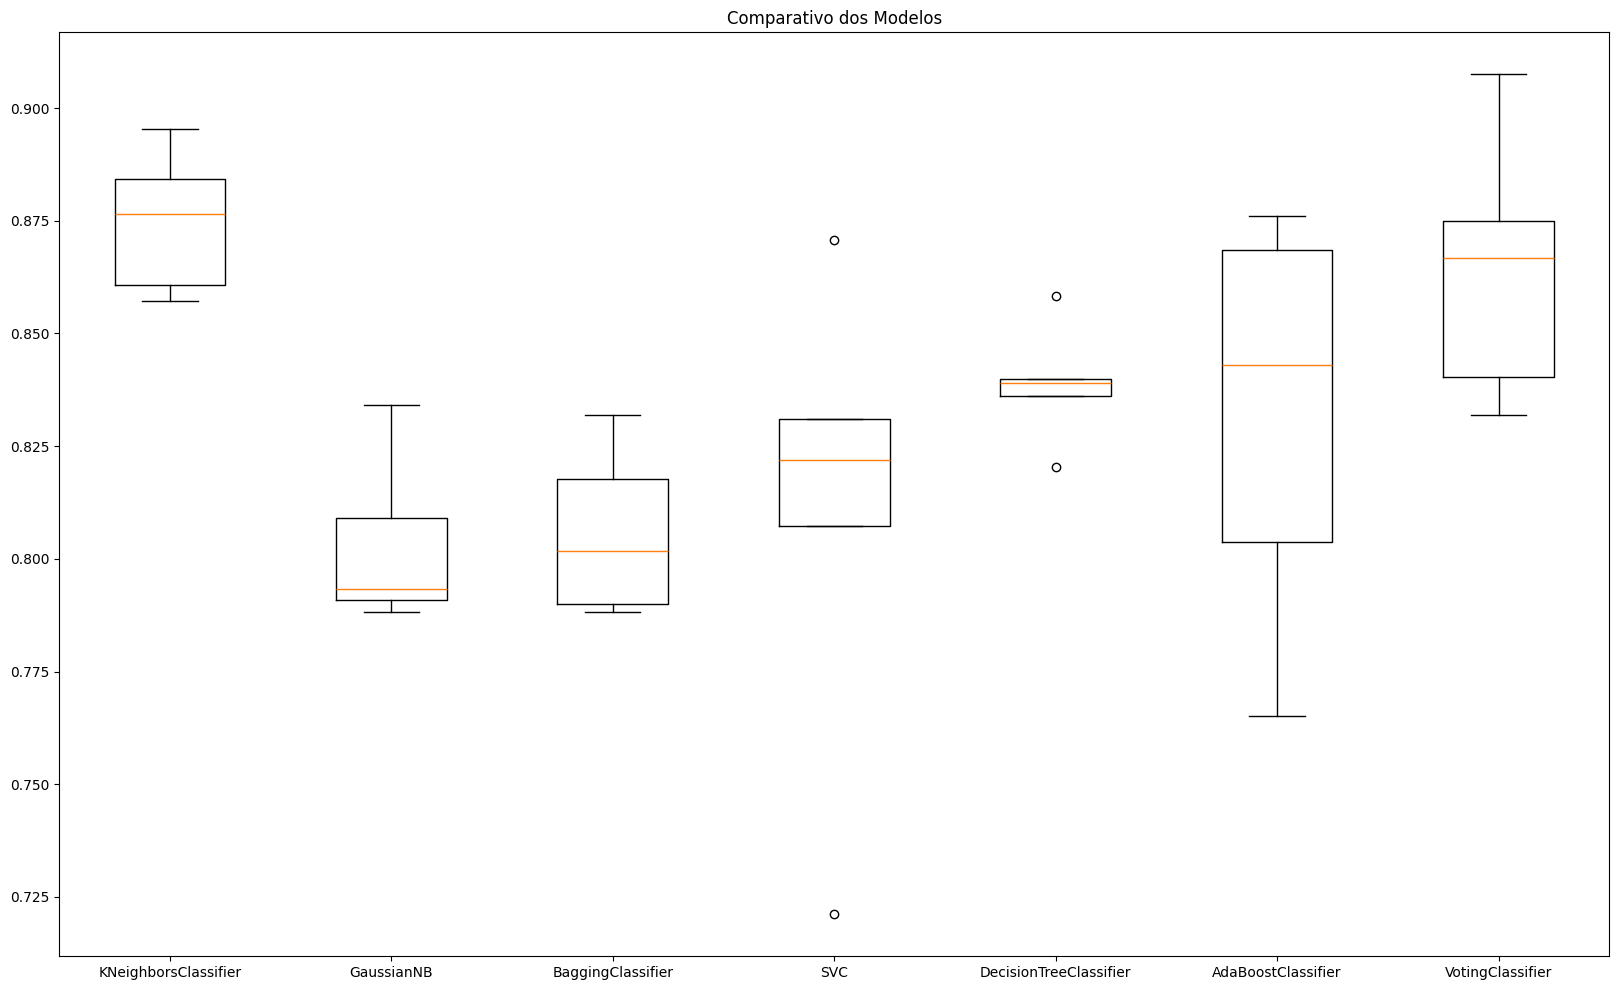

In [18]:
# modelos
models = [knn,
          gnb,
          gnb_bagging,
          svm,
          dt,
          dt_boost,
          voting]

results = []
names = []

X_train, X_test, y_train, y_test = train_test_split(Z, y,
                                                    test_size=.25,
                                                    random_state=42)

fig = plt.figure(figsize=(20,12))

for model in models: # Validacao Cruzada
  ### TODO completar
  cv_results = cross_val_score(model, Z, y, cv=5, scoring='f1')
  names.append(model.__class__.__name__)
  results.append(cv_results)
  
  print('{}: {:.4f} (+/- {:.4f})'.format(model.__class__.__name__, cv_results.mean(), cv_results.std()))

# Comparacao Visual dos Algoritmos
plt.boxplot(results, labels=names)
plt.title('Comparativo dos Modelos')
plt.show()

# Comparativo dos Modelos (Curva ROC)

In [19]:
neural = neural_network.MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(5, 2), random_state=1)
ada_boost = AdaBoostClassifier()

/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/orlandojunior/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


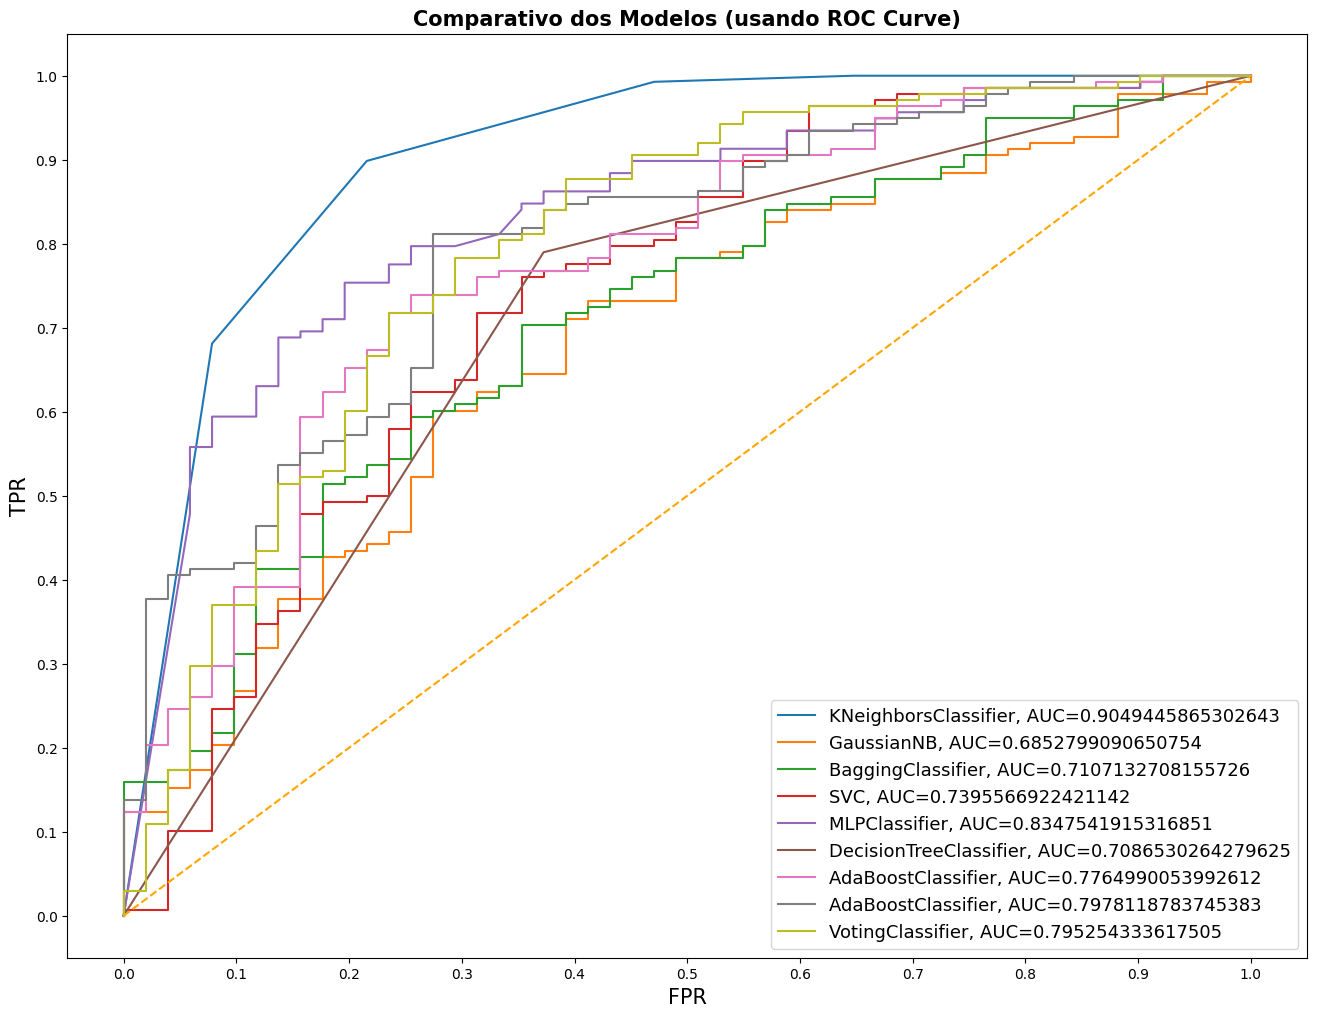

In [20]:
# classificadores a serem avaliados
models = [knn,
          gnb,
          gnb_bagging,
          svm,
          neural,
          dt,
          dt_boost,
          ada_boost,
          voting]

# Treina os modelos a plota os resultados

fig = plt.figure(figsize=(16,12))

for model in models:
    model = model.fit(X_train, y_train)
    yproba = model.predict_proba(X_test)[::,1]

    fpr, tpr, thresholds = roc_curve(y_test,yproba) ###TODO roc curve
    auc = roc_auc_score(y_test,yproba)###TODO auc

    plt.plot(fpr,
             tpr,
             label="{}, AUC={}".format(model.__class__.__name__, auc))

plt.plot([0,1], [0,1], color='orange', linestyle='--')

plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("FPR", fontsize=15)

plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("TPR", fontsize=15)

plt.title('Comparativo dos Modelos (usando ROC Curve)', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')

plt.show()